# ClonalOrigin pair model and its summary statistics for SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from ClonalOrigin_pair_sim import ClonalOrigin_pair_sim

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
np.random.seed(100)
clonal_tree = ClonalTree(n=10)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                   _______ 2
                                        __________________________|
                            ___________|                          |_______ 8
                           |           |
                           |           |___________________________________ 1
                           |
                        ___|                         _____________________ 6
                       |   |                       ,|
                       |   |                       ||  ___________________ 3
                       |   |                       ||_|
                       |   |_______________________|  |___________________ 9
  _____________________|                           |
 |                     |                           |         _____________ 5
 |                     |                           |________|
_|                     |                                    |_____________ 7
 |                  

## Summary statistics

### Get summary statistics for observations

In [3]:
x_obs = ClonalOrigin_pair_sim(clonal_tree, 0.02, 0.05, 1000000, 300, 10000, k_vec=[50, 200, 2000])
x_obs

array([2.00395070e-01, 1.28931108e-01, 8.42978580e-02, 6.11000000e-02,
       1.00000000e-01, 1.16300000e-01, 2.78917222e-01, 2.39061670e-01,
       1.00000000e+04])

In [5]:
x_obs_new = np.full(8, np.nan)
x_obs_new[0] = x_obs[0] - x_obs[1]
x_obs_new[1] = x_obs[0] - x_obs[2]
x_obs_new[2:] = x_obs[3:]
x_obs_new

array([7.14639617e-02, 1.16097212e-01, 6.11000000e-02, 1.00000000e-01,
       1.16300000e-01, 2.78917222e-01, 2.39061670e-01, 1.00000000e+04])

In [7]:
x_500_np = x_obs_new.copy()
x_2000_np = x_obs_new.copy()
x_6000_np = x_obs_new.copy()

x_500_np[7] = 500
x_2000_np[7] = 2000
x_6000_np[7] = 6000

x_o_500 = torch.tensor(x_500_np, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)

x_o_2000 = torch.tensor(x_2000_np, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)

x_o_6000 = torch.tensor(x_6000_np, device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)

In [8]:
x_500_np, x_2000_np, x_6000_np

(array([7.14639617e-02, 1.16097212e-01, 6.11000000e-02, 1.00000000e-01,
        1.16300000e-01, 2.78917222e-01, 2.39061670e-01, 5.00000000e+02]),
 array([7.14639617e-02, 1.16097212e-01, 6.11000000e-02, 1.00000000e-01,
        1.16300000e-01, 2.78917222e-01, 2.39061670e-01, 2.00000000e+03]),
 array([7.14639617e-02, 1.16097212e-01, 6.11000000e-02, 1.00000000e-01,
        1.16300000e-01, 2.78917222e-01, 2.39061670e-01, 6.00000000e+03]))

### Load simulations from ClonalOrigin model

In [15]:
theta1 = np.loadtxt('../data/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/x2.csv', delimiter=",")

x1_new = np.full((x1.shape[0], 8), np.nan)
x1_new[:, 0] = x1[:, 0] - x1[:, 1]
x1_new[:, 1] = x1[:, 0] - x1[:, 2]
x1_new[:, 2:] = x1[:, 3:]

x2_new = np.full((x2.shape[0], 8), np.nan)
x2_new[:, 0] = x2[:, 0] - x2[:, 1]
x2_new[:, 1] = x2[:, 0] - x2[:, 2]
x2_new[:, 2:] = x2[:, 3:]

x = np.vstack([x1_new, x2_new])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(10000, 3) (10000, 8)


In [16]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

In [17]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [18]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 81 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-05-20T23_00_01.593454' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.



Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


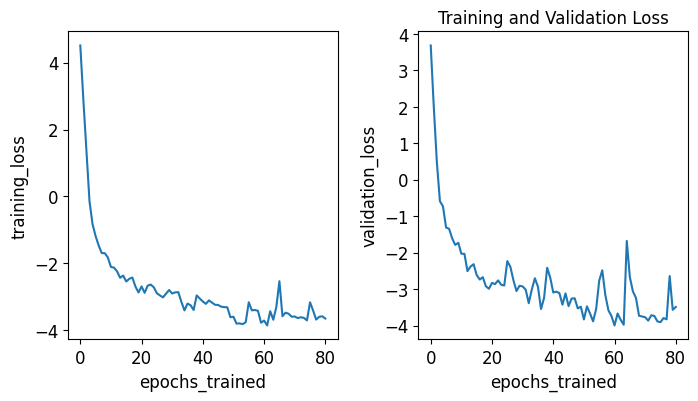

In [19]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### posterior samples

In [21]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 54046.83it/s]


In [22]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 37664.71it/s]


In [23]:
theta_trained_6000 = posterior.set_default_x(x_o_6000).sample((num_posterior_samples,), x=x_o_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 26052.39it/s]


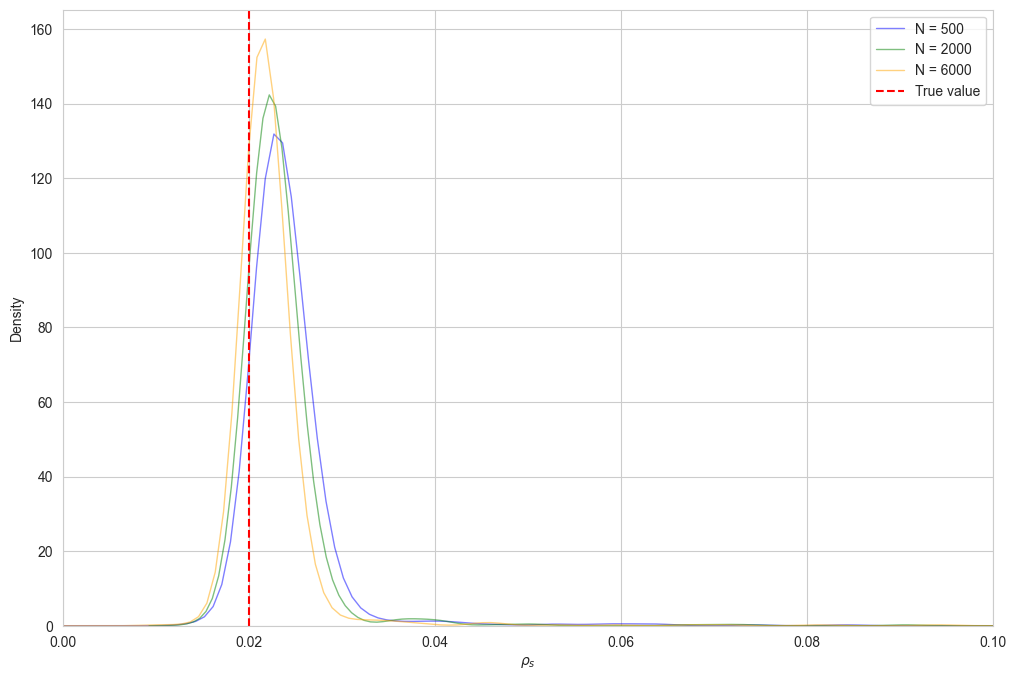

In [24]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

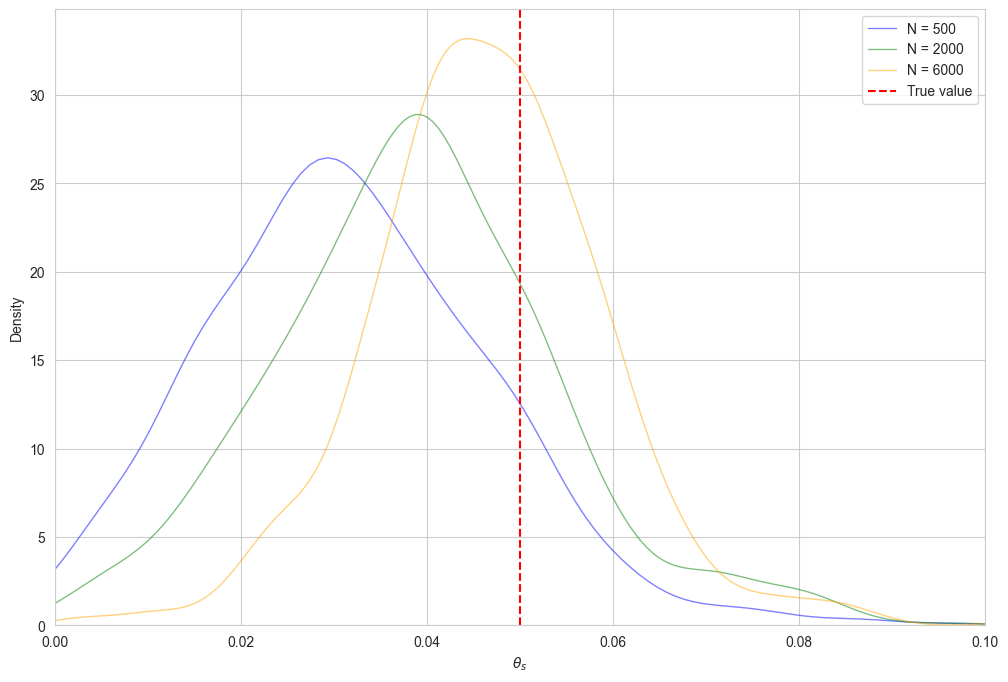

In [25]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

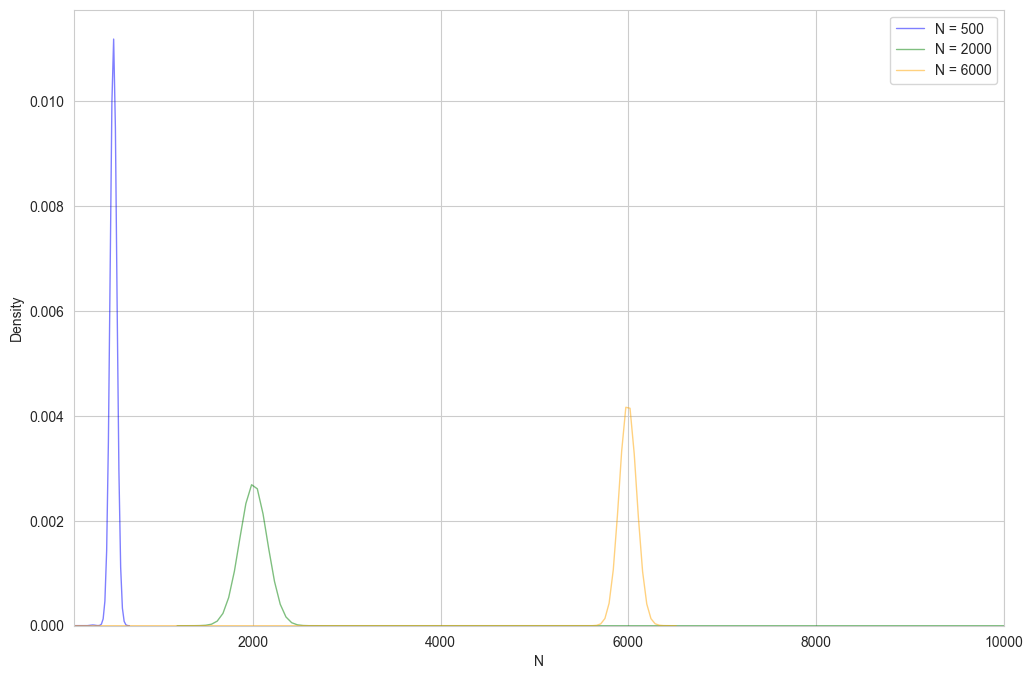

In [26]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

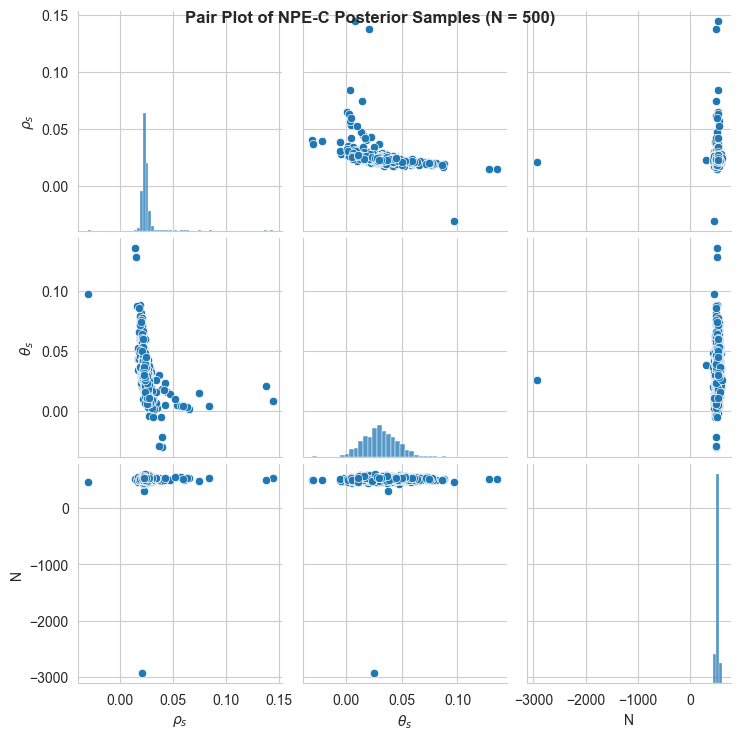

In [27]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

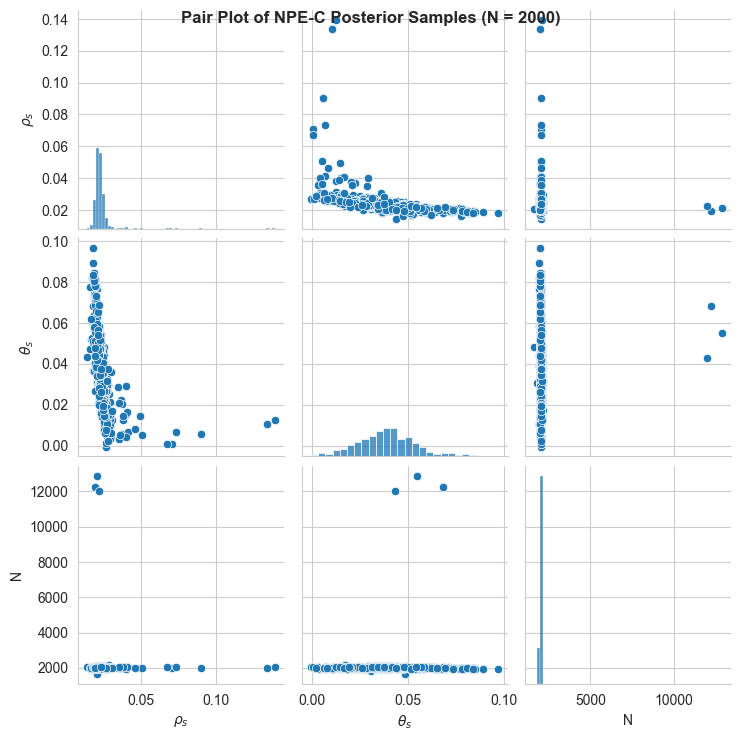

In [28]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

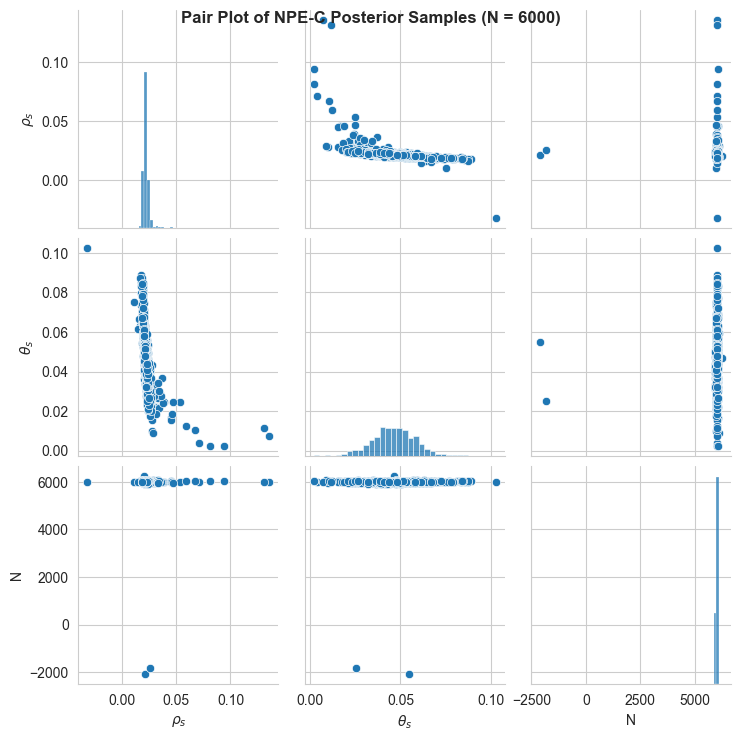

In [29]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

## SBC

In [30]:
theta_sbc = np.loadtxt('../data/theta_sbc.csv', delimiter=",")
theta_sbc = torch.tensor(theta_sbc, device=torch_device)
theta_sbc = theta_sbc.to(torch.float32)
theta_sbc_numpy = theta_sbc.cpu().numpy()
theta_sbc

tensor([[5.5079e-02, 9.4283e-02, 2.4060e+03],
        [8.3514e-02, 1.1756e-02, 7.9490e+03],
        [2.5950e-02, 5.4124e-02, 4.3580e+03],
        ...,
        [4.0726e-02, 9.3280e-02, 5.7980e+03],
        [5.0699e-02, 9.3982e-02, 5.3900e+03],
        [3.8499e-02, 3.9972e-03, 4.6450e+03]])

In [31]:
x_sbc = np.loadtxt('../data/x_sbc.csv', delimiter=",")
x_sbc_new = np.full((x_sbc.shape[0], 8), np.nan)
x_sbc_new[:, 0] = x_sbc[:, 0] - x_sbc[:, 1]
x_sbc_new[:, 1] = x_sbc[:, 0] - x_sbc[:, 2]
x_sbc_new[:, 2:] = x_sbc[:, 3:]

x_sbc = torch.tensor(x_sbc_new, device=torch_device)
x_sbc = x_sbc.to(torch.float32)
x_sbc_numpy = x_sbc.cpu().numpy()
x_sbc

tensor([[5.3156e-02, 7.4113e-02, 1.0765e-01,  ..., 3.5958e-01, 3.5378e-01,
         2.4060e+03],
        [5.9330e-02, 7.0675e-02, 6.9946e-02,  ..., 3.2150e-01, 2.4546e-01,
         7.9490e+03],
        [7.4863e-02, 1.1712e-01, 7.6641e-02,  ..., 3.0323e-01, 2.5558e-01,
         4.3580e+03],
        ...,
        [6.3244e-02, 8.5061e-02, 1.0124e-01,  ..., 3.4672e-01, 2.9839e-01,
         5.7980e+03],
        [5.2078e-02, 7.1317e-02, 1.1466e-01,  ..., 3.5597e-01, 3.0401e-01,
         5.3900e+03],
        [7.5230e-02, 1.1190e-01, 6.6308e-02,  ..., 3.0414e-01, 2.2573e-01,
         4.6450e+03]])

In [32]:
theta_sbc.shape, x_sbc.shape

(torch.Size([500, 3]), torch.Size([500, 8]))

In [33]:
theta_sbc.dtype, x_sbc.dtype

(torch.float32, torch.float32)

In [34]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
ranks, dap_samples = run_sbc(
    theta_sbc, 
    x_sbc, 
    posterior, 
    num_posterior_samples=1000,
    use_batched_sampling=False
)

stats = check_sbc(
    ranks, 
    theta_sbc, 
    dap_samples, 
    num_posterior_samples=1000
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats
})

Calculating ranks for 500 SBC samples: 100%|██████████| 500/500 [00:00<00:00, 12367.03it/s]


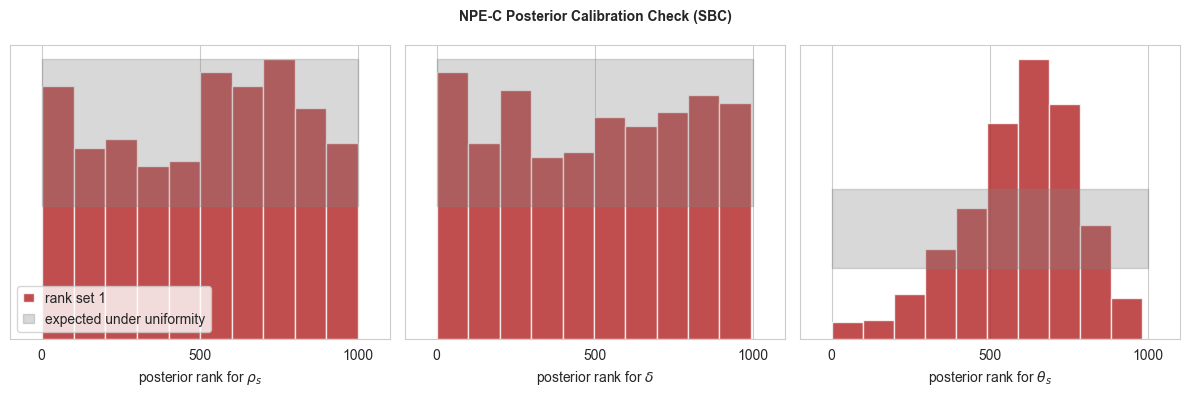

In [35]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(12, 4),
    parameter_labels=[r"for $\rho_s$", r"for $\delta$", r"for $\theta_s$", r"for L"]
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 6))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend()
    plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_36480\3449303370.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranks_np = np.array(ranks)


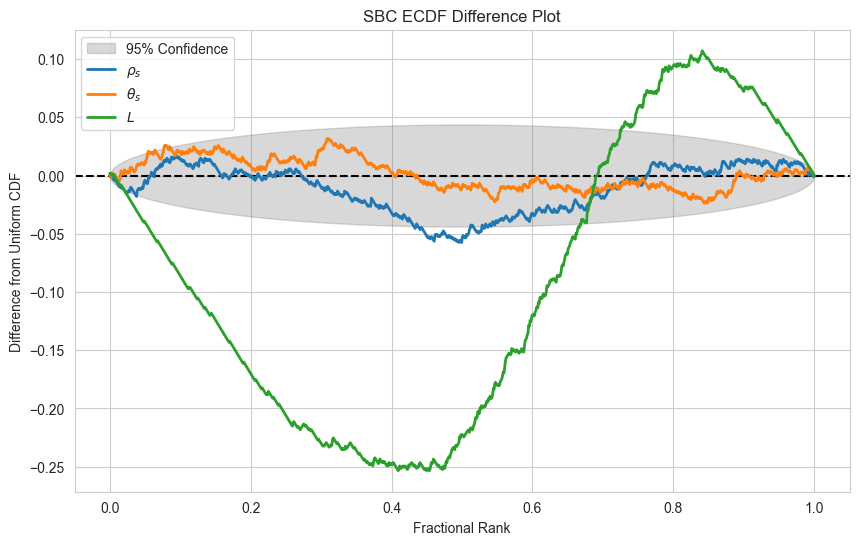

In [37]:
plot_sbc_ecdf_diff(ranks, num_posterior_samples=1000, param_names=[r"$\rho_s$", r"$\theta_s$", r"$L$"])